# 분석 목적

**가입 시점이 비슷한 사용자 집단이 시간이 지나면서 얼마나 남아 있는지** 확인하기 위한 분석

전체 MAU나 월별 이벤트 수만 보면 신규 유입 증가, 관측 기간 차이, 6월 신규 가입 부재 등의 영향이 섞여 실제 리텐션 변화를 해석하기 어렵기 때문에  
따라서 이번 분석에서는 사용자를 **가입월 기준 코호트**로 나누고, 가입 이후 특정 시점에 다시 앱을 실행했는지 확인한다.

이를 통해 단순 "사용자가 감소했다"를 넘어서
-  **어느 가입월 사용자에게서 리텐션 하락이 두드러지는지**,  
- **가입 후 며칠 차에 이탈이 많이 발생하는지**,  
- **온보딩 및 초기 기능 경험과 리텐션이 어떤 관계를 가지는지**

를 확인하는 것을 목표로 한다.

---

## 코호트 분석 기준

| 구분 | 기준 |
|---|---|
| 코호트 기준 | 가입월(`signup_month`) |
| Day 0 기준 | 가입일 |
| 활성 유저 판단 이벤트 | 앱실행 |
| 활성 판단 제외 이벤트 | 알림수신, 알림오픈 |
| 리텐션 목표일 | D0, D3, D7, D30 |
| 리텐션 판정 방식 | 가입일 + N일째 되는 날짜에 앱실행 이벤트가 있는지 확인 |
| 사용자 중복 처리 | 목표일에 앱실행이 여러 번 있어도 사용자 1명은 1명으로 계산 |
| 로그 수집 장애 기간 | 2025-03-10 ~ 2025-03-14 |
| 장애 기간 처리 | 삭제하지 않고 플래그 처리 |
| 주의 필요 코호트 | 2월 D30, 3월 D0/D3/D7 |

In [131]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

In [132]:
# 1. 프로젝트 경로 설정
# 프로젝트 최상위 폴더입니다.
# 본인 PC에서 GitHub 프로젝트가 있는 위치로 바꾸면 됩니다.
ROOT = Path(r"C:\Users\joon5\Documents\github\Anti-Churn-Committee")

# 원본 데이터가 들어있는 폴더
DATA_PROCESSED_DIR = ROOT / "data" / "processed"


# 원본 파일명입니다.
# data/raw 폴더 안에 이 이름으로 파일이 있어야 합니다.
USER_PROFILE_FILE = "01_user_profile_preprocessed.csv"
EVENT_LOG_FILE = "02_event_log_preprocessed.csv"

# 실제로 읽어올 파일 경로를 만듭니다.
USER_PROFILE_PATH = DATA_PROCESSED_DIR / USER_PROFILE_FILE
EVENT_LOG_PATH = DATA_PROCESSED_DIR / EVENT_LOG_FILE

print("USER_PROFILE_PATH:", USER_PROFILE_PATH)
print("EVENT_LOG_PATH   :", EVENT_LOG_PATH)
print("저장 폴더        :", DATA_PROCESSED_DIR)

user_profile = pd.read_csv(USER_PROFILE_PATH)
event_log = pd.read_csv(EVENT_LOG_PATH)

print("user_profile shape:", user_profile.shape)
print("event_log shape:", event_log.shape)

display(user_profile.head())
display(event_log.head())

USER_PROFILE_PATH: C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\01_user_profile_preprocessed.csv
EVENT_LOG_PATH   : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\02_event_log_preprocessed.csv
저장 폴더        : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed
user_profile shape: (12500, 23)
event_log shape: (1757262, 11)


,user_id,signup_date,signup_channel,device,notification_agreed,notification_changed_date,signup_day,signup_month,signup_weekday,first_event_time,first_event_elapsed_hours,first_app_launch_time,app_launch_elapsed_hours,onboarding_completed_time,onboarding_elapsed_hours,app_launch_to_onboarding_hours,is_onboarding_completed,event_count_total,avg_events_per_session,is_signup_log_issue_period,is_no_event_user,is_notification_changed,is_first_event_before_signup
0,U0000001,2025-01-25,오가닉,iOS,True,NaN,2025-01-25,2025-01,토,2025-01-25 07:25:45,7.429167,2025-01-25 07:25:45,7.429167,2025-01-25 07:26:15,7.437500,0.008333,True,515,2.07,False,False,False,False
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24,2025-05-06,2025-05,화,2025-05-06 16:23:12,16.386667,2025-05-06 16:23:12,16.386667,NaN,NaN,NaN,False,55,2.62,False,False,True,False
2,U0000003,2025-05-14,오가닉,iOS,False,NaN,2025-05-14,2025-05,수,2025-05-14 11:09:58,11.166111,2025-05-14 11:09:58,11.166111,NaN,NaN,NaN,False,3,1.50,False,False,False,False
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaN,2025-02-23,2025-02,일,2025-02-23 07:15:35,7.259722,2025-02-23 07:15:35,7.259722,NaN,NaN,NaN,False,89,1.79,False,False,False,False
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaN,2025-02-18,2025-02,화,2025-02-18 12:50:01,12.833611,2025-02-18 12:52:37,12.876944,2025-02-18 12:53:07,12.885278,0.008333,True,442,1.85,False,False,False,False


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False


# 코호트 분석 준비

본격적인 코호트 리텐션 계산에 들어가기 전에, 먼저 분석에 필요한 기준 테이블을 만든다.

1. 사용자별 가입일과 가입월을 정리한다.
2. 이벤트 로그에 가입일, 가입월, 이벤트 날짜를 결합한다.
3. 활성 이벤트인 `앱실행`만 별도로 분리한다.
4. 사용자별 D0, D3, D7, D30 목표일을 생성한다.
5. 목표일에 실제 앱실행이 있었는지 판정할 수 있는 베이스 테이블을 만든다.
6. 이후 단계에서 가입월별 리텐션율을 계산한다.

---

## 1. 분석 기준 정리

| 구분 | 기준 |
|---|---|
| Day 0 | 가입일 |
| 활성 유저 판단 이벤트 | 앱실행 |
| 활성 판단 제외 이벤트 | 알림수신, 알림오픈 |
| 로그 수집 장애 기간 | 2025-03-10 ~ 2025-03-14 |
| 장애 기간 처리 | 삭제하지 않고 플래그 처리 |
| 코호트 기준 | 가입월(`signup_month`) |
| 리텐션 목표일 | D0, D3, D7, D30 |
| 리텐션 판정 방식 | 가입일 + N일째 되는 날짜에 앱실행 이벤트가 있는지 확인 |
| 사용자 중복 처리 | 목표일에 앱실행이 여러 번 있어도 사용자 1명은 1명으로 계산 |
| 주의 필요 코호트 | 2월 D30, 3월 D0/D3/D7 |

In [133]:
# 분석 기준 변수
issue_start = pd.Timestamp("2025-03-10")
issue_end = pd.Timestamp("2025-03-14")

retention_days_list = [0, 3, 7, 30]
active_event_type = "앱실행"
notification_event_types = ["알림수신", "알림오픈"]

analysis_criteria = pd.DataFrame({
    "구분": [
        "Day 0",
        "활성 유저 판단 이벤트",
        "활성 판단 제외 이벤트",
        "로그 수집 장애 기간",
        "코호트 기준",
        "리텐션 목표일"
    ],
    "기준": [
        "가입일",
        active_event_type,
        ", ".join(notification_event_types),
        f"{issue_start.date()} ~ {issue_end.date()}",
        "가입월(signup_month)",
        ", ".join(["D" + str(day) for day in retention_days_list])
    ]
})

display(analysis_criteria)

,구분,기준
0,Day 0,가입일
1,활성 유저 판단 이벤트,앱실행
2,활성 판단 제외 이벤트,"알림수신, 알림오픈"
3,로그 수집 장애 기간,2025-03-10 ~ 2025-03-14
4,코호트 기준,가입월(signup_month)
5,리텐션 목표일,"D0, D3, D7, D30"


## 2. 날짜 컬럼 정리 (안정적인 분석 하기 위함)

In [134]:
# 사용자 프로필 날짜 컬럼 정리
user_profile["signup_date"] = pd.to_datetime(user_profile["signup_date"], errors="coerce")
user_profile["signup_day"] = pd.to_datetime(user_profile["signup_day"], errors="coerce").dt.normalize()
user_profile["signup_month"] = user_profile["signup_day"].dt.to_period("M").astype(str)

if "notification_changed_date" in user_profile.columns:
    user_profile["notification_changed_date"] = pd.to_datetime(
        user_profile["notification_changed_date"],
        errors="coerce"
    )

# 이벤트 로그 날짜 컬럼 정리
event_log["event_time"] = pd.to_datetime(event_log["event_time"], errors="coerce")
event_log["event_date"] = pd.to_datetime(event_log["event_date"], errors="coerce").dt.normalize()
event_log["event_month"] = event_log["event_date"].dt.to_period("M").astype(str)

print("사용자 프로필 날짜 범위")
print("가입일 최소:", user_profile["signup_day"].min())
print("가입일 최대:", user_profile["signup_day"].max())

print()
print("이벤트 로그 날짜 범위")
print("이벤트일 최소:", event_log["event_date"].min())
print("이벤트일 최대:", event_log["event_date"].max())

사용자 프로필 날짜 범위
가입일 최소: 2025-01-01 00:00:00
가입일 최대: 2025-05-26 00:00:00

이벤트 로그 날짜 범위
이벤트일 최소: 2025-01-01 00:00:00
이벤트일 최대: 2025-06-30 00:00:00


## 3. 분석 범위 확인

In [135]:
data_scope_summary = pd.DataFrame({
    "항목": [
        "전체 가입자 수",
        "이벤트 로그 사용자 수",
        "이벤트 로그 행 수",
        "이벤트 없는 가입자 수",
        "로그 장애 기간 가입자 수",
        "가입월 개수",
        "이벤트 관측 시작일",
        "이벤트 관측 종료일"
    ],
    "값": [
        user_profile["user_id"].nunique(),
        event_log["user_id"].nunique(),
        len(event_log),
        int(user_profile["is_no_event_user"].sum()),
        int(user_profile["is_signup_log_issue_period"].sum()),
        user_profile["signup_month"].nunique(),
        event_log["event_date"].min(),
        event_log["event_date"].max()
    ]
})

display(data_scope_summary)

,항목,값
0,전체 가입자 수,12500
1,이벤트 로그 사용자 수,12453
2,이벤트 로그 행 수,1757262
3,이벤트 없는 가입자 수,47
4,로그 장애 기간 가입자 수,341
5,가입월 개수,5
6,이벤트 관측 시작일,2025-01-01 00:00:00
7,이벤트 관측 종료일,2025-06-30 00:00:00


## 3.코호트 기준 사용자 베이스 생성
사용자 1명당 1행인 코호트 기준 테이블       
이후 모든 코호트 분석은 이 테이블의 `signup_month`를 기준으로 묶기

In [136]:
profile_for_cohort = user_profile[[
    "user_id",
    "signup_day",
    "signup_month",
    "signup_channel",
    "device",
    "notification_agreed",
    "is_onboarding_completed",
    "is_no_event_user",
    "is_signup_log_issue_period"
]].copy()

cohort_user_summary = (
    profile_for_cohort
    .groupby("signup_month", as_index=False)
    .agg(
        cohort_user_count=("user_id", "nunique"),
        no_event_user_count=("is_no_event_user", "sum"),
        signup_log_issue_user_count=("is_signup_log_issue_period", "sum"),
        onboarding_completed_user_count=("is_onboarding_completed", "sum")
    )
)

cohort_user_summary["onboarding_completed_rate"] = (
    cohort_user_summary["onboarding_completed_user_count"]
    / cohort_user_summary["cohort_user_count"]
    * 100
).round(2)

display(cohort_user_summary)
display(profile_for_cohort.head())

,signup_month,cohort_user_count,no_event_user_count,signup_log_issue_user_count,onboarding_completed_user_count,onboarding_completed_rate
0,2025-01,2124,0,0,999,47.03
1,2025-02,4384,0,0,2042,46.58
2,2025-03,2122,47,341,899,42.37
3,2025-04,2082,0,0,941,45.20
4,2025-05,1788,0,0,838,46.87


,user_id,signup_day,signup_month,signup_channel,device,notification_agreed,is_onboarding_completed,is_no_event_user,is_signup_log_issue_period
0,U0000001,2025-01-25,2025-01,오가닉,iOS,True,True,False,False
1,U0000002,2025-05-06,2025-05,오가닉,iOS,False,False,False,False
2,U0000003,2025-05-14,2025-05,오가닉,iOS,False,False,False,False
3,U0000004,2025-02-23,2025-02,퍼포먼스광고,Android,True,False,False,False
4,U0000005,2025-02-18,2025-02,퍼포먼스광고,Android,True,True,False,False


## 4. 리텐션 분석용 이벤트 기준 테이블 생성

이벤트 로그에 사용자 가입 정보를 결합해 리텐션 판정에 필요로한 이밴트 기준 컬럼을 생성

In [137]:
profile_for_merge = user_profile[[
    "user_id",
    "signup_day",
    "signup_month",
    "is_no_event_user",
    "is_signup_log_issue_period"
]].copy()

event_log_retention_base = event_log.merge(
    profile_for_merge,
    on="user_id",
    how="left"
)

event_log_retention_base["event_day_from_signup"] = (
    event_log_retention_base["event_date"] - event_log_retention_base["signup_day"]
).dt.days

event_log_retention_base["is_retention_active_event"] = (
    event_log_retention_base["event_type"].eq(active_event_type)
)

event_log_retention_base["is_notification_event"] = (
    event_log_retention_base["event_type"].isin(notification_event_types)
)

event_log_retention_base["is_event_before_signup"] = (
    event_log_retention_base["event_day_from_signup"].lt(0)
)

retention_base_check = pd.DataFrame({
    "항목": [
        "이벤트 로그 행 수",
        "프로필과 매칭되지 않은 이벤트 수",
        "가입일 이전 이벤트 수",
        "리텐션 활성 이벤트 수",
        "알림 이벤트 수",
        "로그 장애 기간 이벤트 수"
    ],
    "값": [
        len(event_log_retention_base),
        int(event_log_retention_base["signup_day"].isna().sum()),
        int(event_log_retention_base["is_event_before_signup"].sum()),
        int(event_log_retention_base["is_retention_active_event"].sum()),
        int(event_log_retention_base["is_notification_event"].sum()),
        int(event_log_retention_base["is_log_issue_period"].sum())
    ]
})

display(retention_base_check)
display(event_log_retention_base.head())

,항목,값
0,이벤트 로그 행 수,1757262
1,프로필과 매칭되지 않은 이벤트 수,0
2,가입일 이전 이벤트 수,0
3,리텐션 활성 이벤트 수,728657
4,알림 이벤트 수,215543
5,로그 장애 기간 이벤트 수,20862


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,event_day_from_signup,is_retention_active_event,is_notification_event,is_event_before_signup
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,True,False,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False,2025-01-25,2025-01,False,False,0,False,True,False


## 5. 활성 이벤트 일 단위 테이블 생성

기준에 의해 리텐션 판정은 `가입일 + N일째 되는 날짜에 앱실행 이벤트가 있는지`로 확인

In [138]:
active_event_daily = (
    event_log_retention_base
    .loc[event_log_retention_base["is_retention_active_event"], ["user_id", "event_date"]]
    .drop_duplicates()
    .rename(columns={"event_date": "active_event_date"})
)

active_event_daily["has_active_event_on_target_date"] = True

active_event_daily_summary = pd.DataFrame({
    "항목": [
        "일 단위 앱실행 행 수",
        "앱실행 사용자 수",
        "앱실행 발생일 수"
    ],
    "값": [
        len(active_event_daily),
        active_event_daily["user_id"].nunique(),
        active_event_daily["active_event_date"].nunique()
    ]
})

display(active_event_daily_summary)
display(active_event_daily.head())

,항목,값
0,일 단위 앱실행 행 수,307753
1,앱실행 사용자 수,12447
2,앱실행 발생일 수,181


,user_id,active_event_date,has_active_event_on_target_date
0,U0000001,2025-01-25,True
5,U0000001,2025-01-26,True
18,U0000001,2025-01-27,True
33,U0000001,2025-01-28,True
39,U0000001,2025-01-29,True


## 6. 사용자별 리텐션 목표일 생성 

사용자별로 D0, D3, D7, D30 목표일을 생성

In [139]:
retention_day_df = pd.DataFrame({
    "retention_day": retention_days_list
})

user_retention_targets = (
    user_profile[[
        "user_id",
        "signup_day",
        "signup_month",
        "is_no_event_user",
        "is_signup_log_issue_period"
    ]]
    .merge(retention_day_df, how="cross")
)

user_retention_targets["target_date"] = (
    user_retention_targets["signup_day"]
    + pd.to_timedelta(user_retention_targets["retention_day"], unit="D")
)

user_retention_targets["retention_label"] = (
    "D" + user_retention_targets["retention_day"].astype(str)
)

event_observation_start = event_log["event_date"].min()
event_observation_end = event_log["event_date"].max()

user_retention_targets["is_target_observable"] = (
    user_retention_targets["target_date"].between(
        event_observation_start,
        event_observation_end
    )
)

user_retention_targets["is_target_log_issue_period"] = (
    user_retention_targets["target_date"].between(
        issue_start,
        issue_end
    )
)

user_retention_targets["is_retention_calculation_target"] = (
    user_retention_targets["is_target_observable"]
    & ~user_retention_targets["is_target_log_issue_period"]
)

user_retention_targets["retention_target_status"] = np.select(
    [
        ~user_retention_targets["is_target_observable"],
        user_retention_targets["is_target_log_issue_period"],
        user_retention_targets["is_retention_calculation_target"]
    ],
    [
        "관측 불가",
        "장애기간 중복",
        "정상 산정 가능"
    ],
    default="확인 필요"
)

display(user_retention_targets.head())

,user_id,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,retention_day,target_date,retention_label,is_target_observable,is_target_log_issue_period,is_retention_calculation_target,retention_target_status
0,U0000001,2025-01-25,2025-01,False,False,0,2025-01-25,D0,True,False,True,정상 산정 가능
1,U0000001,2025-01-25,2025-01,False,False,3,2025-01-28,D3,True,False,True,정상 산정 가능
2,U0000001,2025-01-25,2025-01,False,False,7,2025-02-01,D7,True,False,True,정상 산정 가능
3,U0000001,2025-01-25,2025-01,False,False,30,2025-02-24,D30,True,False,True,정상 산정 가능
4,U0000002,2025-05-06,2025-05,False,False,0,2025-05-06,D0,True,False,True,정상 산정 가능


## 7. 가입월별 목표일 산정 가능 범위 확인
가입월 코호트별로 D0, D3, D7, D30 목표일이 정상 산정 가능한지 확인

In [140]:
cohort_target_summary = (
    user_retention_targets
    .groupby(["signup_month", "retention_day", "retention_label"], as_index=False)
    .agg(
        cohort_user_count=("user_id", "nunique"),
        observable_user_count=("is_target_observable", "sum"),
        log_issue_target_user_count=("is_target_log_issue_period", "sum"),
        calculation_target_user_count=("is_retention_calculation_target", "sum")
    )
)

cohort_target_summary["normal_target_user_count"] = (
    cohort_target_summary["observable_user_count"]
    - cohort_target_summary["log_issue_target_user_count"]
)

cohort_target_summary["observable_rate"] = (
    cohort_target_summary["observable_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

cohort_target_summary["normal_target_rate"] = (
    cohort_target_summary["normal_target_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

cohort_target_summary["log_issue_target_rate"] = (
    cohort_target_summary["log_issue_target_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

cohort_target_summary["calculation_target_rate"] = (
    cohort_target_summary["calculation_target_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

cohort_target_summary["retention_label"] = pd.Categorical(
    cohort_target_summary["retention_label"],
    categories=["D0", "D3", "D7", "D30"],
    ordered=True
)

cohort_target_summary = cohort_target_summary.sort_values(
    ["signup_month", "retention_label"]
)

display(cohort_target_summary)

,signup_month,retention_day,retention_label,cohort_user_count,observable_user_count,log_issue_target_user_count,calculation_target_user_count,normal_target_user_count,observable_rate,normal_target_rate,log_issue_target_rate,calculation_target_rate
0,2025-01,0,D0,2124,2124,0,2124,2124,100.0,100.00,0.00,100.00
1,2025-01,3,D3,2124,2124,0,2124,2124,100.0,100.00,0.00,100.00
2,2025-01,7,D7,2124,2124,0,2124,2124,100.0,100.00,0.00,100.00
3,2025-01,30,D30,2124,2124,0,2124,2124,100.0,100.00,0.00,100.00
4,2025-02,0,D0,4384,4384,0,4384,4384,100.0,100.00,0.00,100.00
5,2025-02,3,D3,4384,4384,0,4384,4384,100.0,100.00,0.00,100.00
6,2025-02,7,D7,4384,4384,0,4384,4384,100.0,100.00,0.00,100.00
7,2025-02,30,D30,4384,4384,771,3613,3613,100.0,82.41,17.59,82.41
8,2025-03,0,D0,2122,2122,341,1781,1781,100.0,83.93,16.07,83.93
9,2025-03,3,D3,2122,2122,341,1781,1781,100.0,83.93,16.07,83.93


# 본격적인 리텐션+코호트 분석

사용자별 목표일 테이블과 일 단위 앱실행 테이블을 결합

In [141]:
user_retention_judgement_base = user_retention_targets.merge(
    active_event_daily,
    left_on=["user_id", "target_date"],
    right_on=["user_id", "active_event_date"],
    how="left"
)

user_retention_judgement_base["has_active_event_on_target_date"] = (
    user_retention_judgement_base["has_active_event_on_target_date"]
    .fillna(False)
    .astype(bool)
)

user_retention_judgement_base["is_retained_raw"] = (
    user_retention_judgement_base["has_active_event_on_target_date"]
)

user_retention_judgement_base["is_retained_for_calculation"] = (
    user_retention_judgement_base["is_retained_raw"]
    & user_retention_judgement_base["is_retention_calculation_target"]
)

user_retention_judgement_base = user_retention_judgement_base.drop(
    columns=["active_event_date"]
)

display(user_retention_judgement_base.head())
print("리텐션 판정용 베이스 테이블 shape:", user_retention_judgement_base.shape)

,user_id,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,retention_day,target_date,retention_label,is_target_observable,is_target_log_issue_period,is_retention_calculation_target,retention_target_status,has_active_event_on_target_date,is_retained_raw,is_retained_for_calculation
0,U0000001,2025-01-25,2025-01,False,False,0,2025-01-25,D0,True,False,True,정상 산정 가능,True,True,True
1,U0000001,2025-01-25,2025-01,False,False,3,2025-01-28,D3,True,False,True,정상 산정 가능,True,True,True
2,U0000001,2025-01-25,2025-01,False,False,7,2025-02-01,D7,True,False,True,정상 산정 가능,True,True,True
3,U0000001,2025-01-25,2025-01,False,False,30,2025-02-24,D30,True,False,True,정상 산정 가능,True,True,True
4,U0000002,2025-05-06,2025-05,False,False,0,2025-05-06,D0,True,False,True,정상 산정 가능,True,True,True


리텐션 판정용 베이스 테이블 shape: (50000, 15)


## 1. 가입월별 리텐션율 계산

가입월별로 D0, D3, D7, D30 리텐션율을 계산

In [142]:
retention_order = ["D0", "D3", "D7", "D30"]

cohort_retention_summary = (
    user_retention_judgement_base
    .groupby(["signup_month", "retention_day", "retention_label"], as_index=False)
    .agg(
        cohort_user_count=("user_id", "nunique"),
        calculation_target_user_count=("is_retention_calculation_target", "sum"),
        retained_user_count=("is_retained_for_calculation", "sum"),
        raw_retained_user_count=("is_retained_raw", "sum"),
        log_issue_target_user_count=("is_target_log_issue_period", "sum"),
        observable_user_count=("is_target_observable", "sum")
    )
)

cohort_retention_summary["retention_rate"] = (
    cohort_retention_summary["retained_user_count"]
    / cohort_retention_summary["calculation_target_user_count"]
    * 100
).round(2)

cohort_retention_summary["raw_retention_rate"] = (
    cohort_retention_summary["raw_retained_user_count"]
    / cohort_retention_summary["cohort_user_count"]
    * 100
).round(2)

cohort_retention_summary["retention_label"] = pd.Categorical(
    cohort_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

cohort_retention_summary = cohort_retention_summary.sort_values(
    ["signup_month", "retention_label"]
)

cohort_retention_summary = cohort_retention_summary[[
    "signup_month",
    "retention_label",
    "cohort_user_count",
    "calculation_target_user_count",
    "retained_user_count",
    "retention_rate",
    "raw_retention_rate",
    "log_issue_target_user_count"
]]

display(cohort_retention_summary)

,signup_month,retention_label,cohort_user_count,calculation_target_user_count,retained_user_count,retention_rate,raw_retention_rate,log_issue_target_user_count
0,2025-01,D0,2124,2124,2120,99.81,99.81,0
1,2025-01,D3,2124,2124,1499,70.57,70.57,0
2,2025-01,D7,2124,2124,849,39.97,39.97,0
3,2025-01,D30,2124,2124,480,22.60,22.60,0
4,2025-02,D0,4384,4384,4375,99.79,99.79,0
5,2025-02,D3,4384,4384,3344,76.28,76.28,0
6,2025-02,D7,4384,4384,2060,46.99,46.99,0
7,2025-02,D30,4384,3613,1178,32.60,29.01,771
8,2025-03,D0,2122,1781,1775,99.66,88.83,341
9,2025-03,D3,2122,1781,1288,72.32,64.66,341


### 가입월별 리텐션 흐름

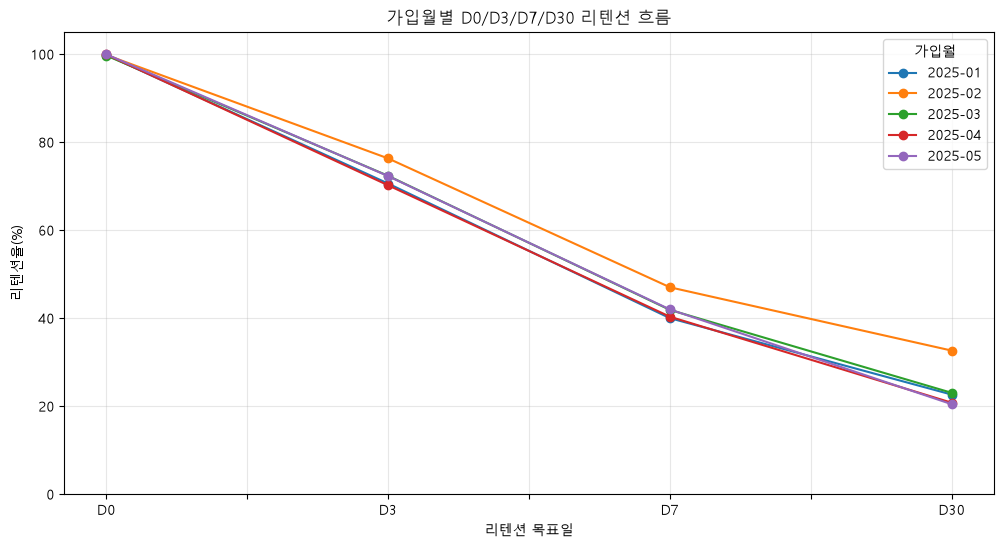

In [143]:
cohort_retention_graph_data = cohort_retention_summary.copy()
cohort_retention_graph_data["retention_label"] = cohort_retention_graph_data["retention_label"].astype(str)

cohort_retention_plot_data = (
    cohort_retention_graph_data
    .pivot(index="retention_label", columns="signup_month", values="retention_rate")
    .reindex(retention_order)
)

ax = cohort_retention_plot_data.plot(marker="o", figsize=(12, 6))
ax.set_title("가입월별 D0/D3/D7/D30 리텐션 흐름")
ax.set_xlabel("리텐션 목표일")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(title="가입월")
plt.show()

### 가입월별 D30 리텐션 비교

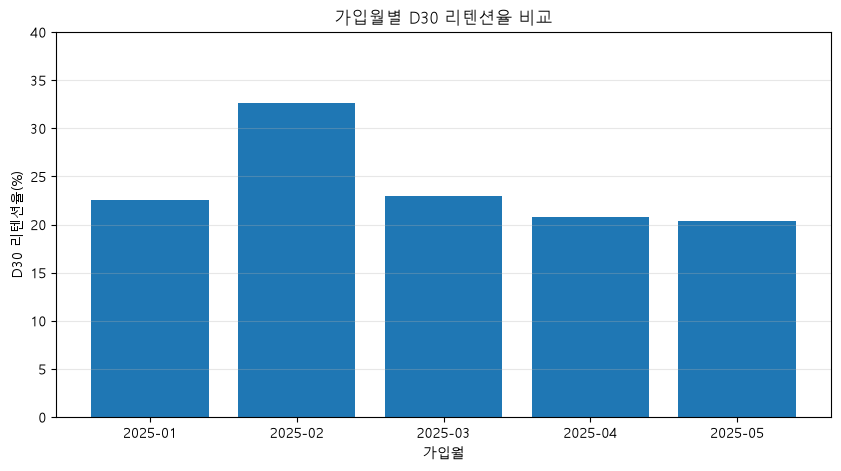

In [144]:
d30_retention_plot_data = (
    cohort_retention_graph_data
    .loc[cohort_retention_graph_data["retention_label"].eq("D30"), ["signup_month", "retention_rate"]]
    .sort_values("signup_month")
)

plt.figure(figsize=(10, 5))
plt.bar(
    d30_retention_plot_data["signup_month"],
    d30_retention_plot_data["retention_rate"]
)
plt.title("가입월별 D30 리텐션율 비교")
plt.xlabel("가입월")
plt.ylabel("D30 리텐션율(%)")
plt.ylim(0, 40)
plt.grid(axis="y", alpha=0.3)
plt.show()

### 분석 결과 해석
전체적으로 D0 리텐션은 모든 가입월에서 약 99.7% 이상으로 매우 높다.  
따라서 가입 직후 앱을 처음 실행하는 단계는 큰 병목으로 보기 어렵다.

반면 D3, D7, D30으로 갈수록 리텐션이 빠르게 낮아진다.  
특히 D7 리텐션은 대부분의 가입월에서 40% 초반 수준까지 내려가고, D30 리텐션은 20% 초반 수준까지 하락한다.

2월 가입자는 가입자 수가 가장 많았지만, D3 76.28%, D7 46.99%, D30 32.60%로 가장 높은 리텐션을 보인다.  
따라서 2월 가입자 수 급증 자체를 리텐션 하락의 직접 원인으로 보기는 어렵다.

오히려 4월과 5월 가입자는 D30 리텐션이 각각 20.75%, 20.41%로 낮다.  
이는 최근 가입 코호트에서 장기 잔존이 약해졌을 가능성을 보여준다.


## 2. 가입월별 리텐션율 표 생성

In [145]:
retention_rate_matrix = (
    cohort_retention_summary
    .pivot(index="signup_month", columns="retention_label", values="retention_rate")
    .reset_index()
)

retained_count_matrix = (
    cohort_retention_summary
    .pivot(index="signup_month", columns="retention_label", values="retained_user_count")
    .reset_index()
)

calculation_target_matrix = (
    cohort_retention_summary
    .pivot(index="signup_month", columns="retention_label", values="calculation_target_user_count")
    .reset_index()
)

print("가입월별 리텐션율")
display(retention_rate_matrix)

print("가입월별 리텐션 유지 사용자 수")
display(retained_count_matrix)

print("가입월별 리텐션 산정 가능 사용자 수")
display(calculation_target_matrix)

가입월별 리텐션율


retention_label,signup_month,D0,D3,D7,D30
0,2025-01,99.81,70.57,39.97,22.60
1,2025-02,99.79,76.28,46.99,32.60
2,2025-03,99.66,72.32,41.85,23.00
3,2025-04,99.90,70.17,40.30,20.75
4,2025-05,99.94,72.26,41.95,20.41


가입월별 리텐션 유지 사용자 수


retention_label,signup_month,D0,D3,D7,D30
0,2025-01,2120,1499,849,480
1,2025-02,4375,3344,2060,1178
2,2025-03,1775,1288,734,488
3,2025-04,2080,1461,839,432
4,2025-05,1787,1292,750,365


가입월별 리텐션 산정 가능 사용자 수


retention_label,signup_month,D0,D3,D7,D30
0,2025-01,2124,2124,2124,2124
1,2025-02,4384,4384,4384,3613
2,2025-03,1781,1781,1754,2122
3,2025-04,2082,2082,2082,2082
4,2025-05,1788,1788,1788,1788


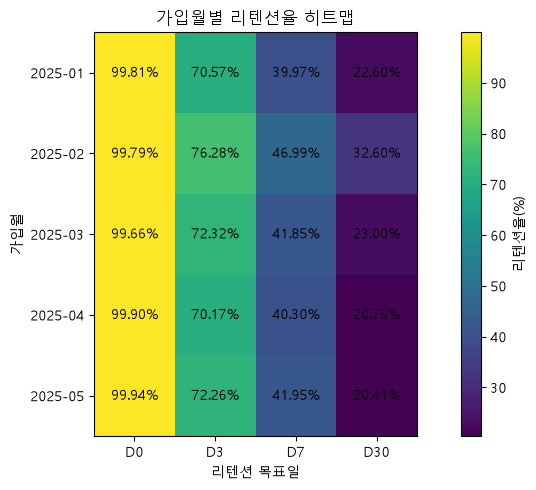

In [146]:
retention_rate_heatmap_data = (
    retention_rate_matrix
    .set_index("signup_month")[retention_order]
    .astype(float)
)

fig, ax = plt.subplots(figsize=(9, 5))
heatmap = ax.imshow(retention_rate_heatmap_data.values)

ax.set_title("가입월별 리텐션율 히트맵")
ax.set_xlabel("리텐션 목표일")
ax.set_ylabel("가입월")

ax.set_xticks(range(len(retention_rate_heatmap_data.columns)))
ax.set_xticklabels(retention_rate_heatmap_data.columns)
ax.set_yticks(range(len(retention_rate_heatmap_data.index)))
ax.set_yticklabels(retention_rate_heatmap_data.index)

for y in range(retention_rate_heatmap_data.shape[0]):
    for x in range(retention_rate_heatmap_data.shape[1]):
        value = retention_rate_heatmap_data.iloc[y, x]
        ax.text(x, y, f"{value:.2f}%", ha="center", va="center")

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("리텐션율(%)")

plt.tight_layout()
plt.show()

### 분석 결과 해석
가입월별 리텐션율을 보면 모든 코호트에서 D0 리텐션은 99% 이상으로 높게 나타난다.        
하지만 D3, D7, D30으로 갈수록 리텐션율은 점차 감소한다.

D30 기준으로는 2월 코호트가 32.60%로 가장 높고, 4월과 5월 코호트는 각각 20.75%, 20.41%로 낮게 나타난다.

다만 2월 D30과 3월 초반 D0/D3/D7 일부는 로그 수집 장애기간과 겹칠 수 있다.      
따라서 해당 구간은 단순 수치만으로 해석하기보다는, 최종 보고서에서 해석 주의 구간으로 두고 분석해야 한다.

## 3. 이탈 구간 확인

D0 → D3, D3 → D7, D7 → D30 구간별 하락폭을 계산한다.  
이를 통해 가입 이후 어느 시점에서 이탈이 가장 크게 발생하는지 확인한다.

In [147]:
retention_drop_summary = retention_rate_matrix.copy()

retention_drop_summary["D0_to_D3_drop_pp"] = (
    retention_drop_summary["D0"] - retention_drop_summary["D3"]
).round(2)

retention_drop_summary["D3_to_D7_drop_pp"] = (
    retention_drop_summary["D3"] - retention_drop_summary["D7"]
).round(2)

retention_drop_summary["D7_to_D30_drop_pp"] = (
    retention_drop_summary["D7"] - retention_drop_summary["D30"]
).round(2)

retention_drop_summary["D0_to_D30_drop_pp"] = (
    retention_drop_summary["D0"] - retention_drop_summary["D30"]
).round(2)

retention_drop_summary = retention_drop_summary[[
    "signup_month",
    "D0", "D3", "D7", "D30",
    "D0_to_D3_drop_pp",
    "D3_to_D7_drop_pp",
    "D7_to_D30_drop_pp",
    "D0_to_D30_drop_pp"
]]

display(retention_drop_summary)

retention_label,signup_month,D0,D3,D7,D30,D0_to_D3_drop_pp,D3_to_D7_drop_pp,D7_to_D30_drop_pp,D0_to_D30_drop_pp
0,2025-01,99.81,70.57,39.97,22.60,29.24,30.60,17.37,77.21
1,2025-02,99.79,76.28,46.99,32.60,23.51,29.29,14.39,67.19
2,2025-03,99.66,72.32,41.85,23.00,27.34,30.47,18.85,76.66
3,2025-04,99.90,70.17,40.30,20.75,29.73,29.87,19.55,79.15
4,2025-05,99.94,72.26,41.95,20.41,27.68,30.31,21.54,79.53


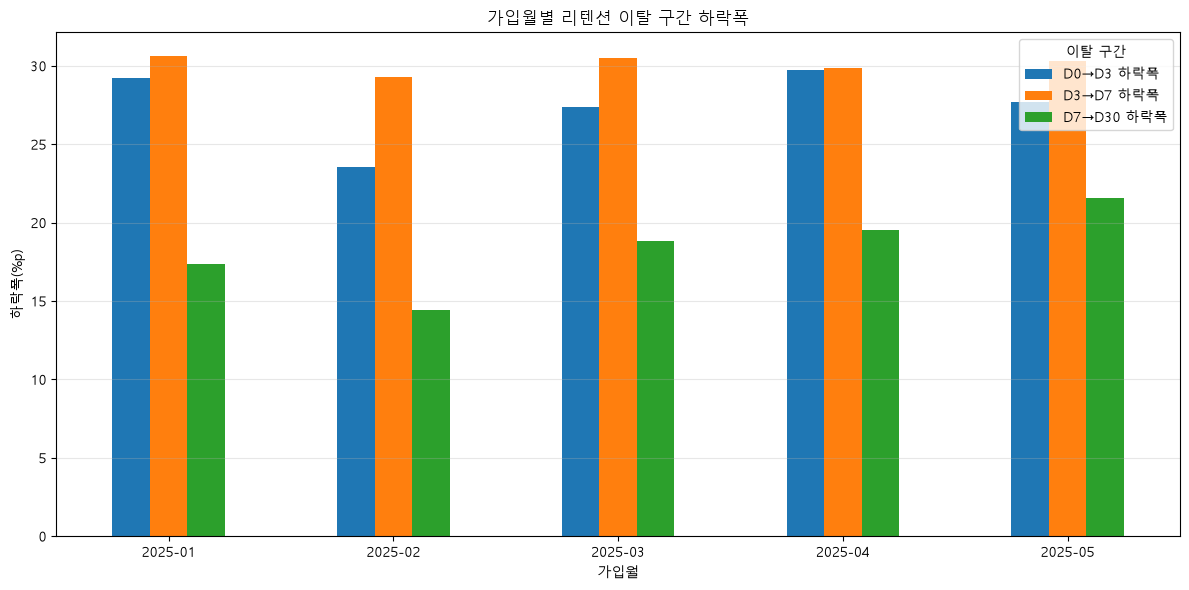

In [148]:
drop_plot_data = (
    retention_drop_summary
    .set_index("signup_month")[[
        "D0_to_D3_drop_pp",
        "D3_to_D7_drop_pp",
        "D7_to_D30_drop_pp"
    ]]
)

drop_plot_data.columns = [
    "D0→D3 하락폭",
    "D3→D7 하락폭",
    "D7→D30 하락폭"
]

ax = drop_plot_data.plot(kind="bar", figsize=(12, 6))
ax.set_title("가입월별 리텐션 이탈 구간 하락폭")
ax.set_xlabel("가입월")
ax.set_ylabel("하락폭(%p)")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="이탈 구간")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 분석 결과 해석

가장 반복적으로 큰 이탈이 발생하는 구간은 **D3 → D7 구간**이다.  
모든 가입월에서 D3 → D7 하락폭이 약 29~31%p 수준으로 나타난다.

즉, 사용자가 가입 직후 3일 차까지는 어느 정도 남아 있지만, 7일 차로 넘어가는 과정에서 큰 폭으로 이탈한다.  
따라서 리텐션 개선의 1차 타겟 구간은 가입 직후가 아니라 **가입 후 3일 차부터 7일 차 사이**로 보는 것이 적절하다.

또한 D7 → D30 하락폭은 최근 코호트로 갈수록 커지는 흐름이 있다.  
특히 5월 코호트는 D7 → D30 하락폭이 21.54%p로 가장 크다.  
이는 초기 사용 후 장기 루틴으로 이어지는 과정이 약해졌을 가능성을 보여준다.

## 4. 로그 수집 장애기간 영향 확인

In [149]:
issue_sensitive_cohort_check = cohort_retention_summary[
    cohort_retention_summary["log_issue_target_user_count"] > 0
].copy()

issue_sensitive_cohort_check["raw_vs_normal_gap_pp"] = (
    issue_sensitive_cohort_check["retention_rate"]
    - issue_sensitive_cohort_check["raw_retention_rate"]
).round(2)

issue_sensitive_cohort_check = issue_sensitive_cohort_check[[
    "signup_month",
    "retention_label",
    "cohort_user_count",
    "calculation_target_user_count",
    "log_issue_target_user_count",
    "retention_rate",
    "raw_retention_rate",
    "raw_vs_normal_gap_pp"
]]

display(issue_sensitive_cohort_check)

,signup_month,retention_label,cohort_user_count,calculation_target_user_count,log_issue_target_user_count,retention_rate,raw_retention_rate,raw_vs_normal_gap_pp
7,2025-02,D30,4384,3613,771,32.60,29.01,3.59
8,2025-03,D0,2122,1781,341,99.66,88.83,10.83
9,2025-03,D3,2122,1781,341,72.32,64.66,7.66
10,2025-03,D7,2122,1754,368,41.85,36.66,5.19


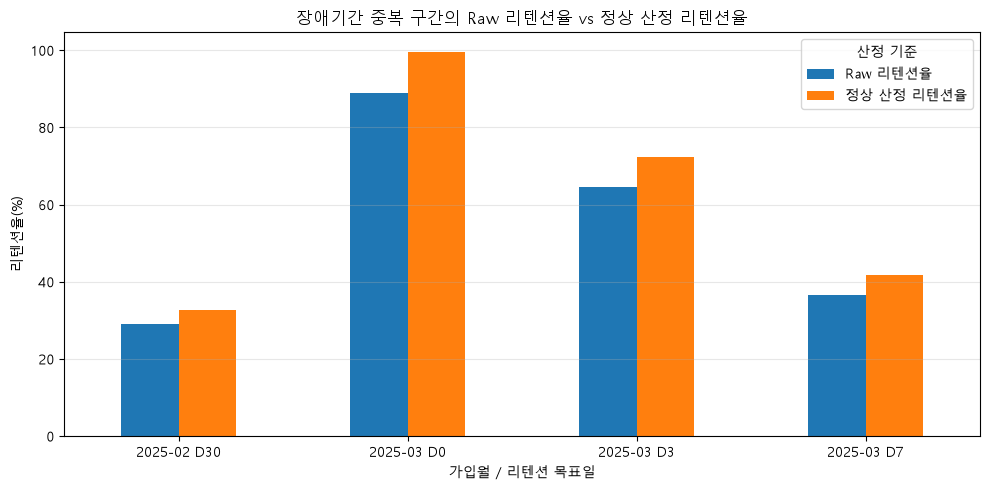

In [150]:
issue_sensitive_plot_data = issue_sensitive_cohort_check.copy()
issue_sensitive_plot_data["cohort_target"] = (
    issue_sensitive_plot_data["signup_month"].astype(str)
    + " "
    + issue_sensitive_plot_data["retention_label"].astype(str)
)

issue_sensitive_plot_data = issue_sensitive_plot_data.set_index("cohort_target")[[
    "raw_retention_rate",
    "retention_rate"
]]

issue_sensitive_plot_data.columns = [
    "Raw 리텐션율",
    "정상 산정 리텐션율"
]

ax = issue_sensitive_plot_data.plot(kind="bar", figsize=(10, 5))
ax.set_title("장애기간 중복 구간의 Raw 리텐션율 vs 정상 산정 리텐션율")
ax.set_xlabel("가입월 / 리텐션 목표일")
ax.set_ylabel("리텐션율(%)")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="산정 기준")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 분석 결과 해석

장애기간 영향은 2월 D30과 3월 D0/D3/D7에서 발생한다.

특히 3월 D0는 전체 기준으로 보면 88.83%까지 낮아지지만, 장애기간 중복 사용자를 제외한 정상 산정 가능 기준에서는 99.66%로 회복된다.  
따라서 3월 초반 리텐션을 그대로 비교하면 로그 수집 장애로 인한 과소평가가 발생할 수 있다.

2월 D30도 장애기간 중복 사용자가 771명 존재한다.  
다만 정상 산정 가능 기준으로 보더라도 32.60%로 가장 높은 D30 리텐션을 보이기 때문에, 2월 코호트는 여전히 상대적으로 좋은 코호트로 해석할 수 있다.

# 최종 해석

이번 코호트 분석에서 확인한 핵심 내용은 다음과 같다.

1. **D0 리텐션은 모든 가입월에서 약 99.7% 이상**이다.  
   가입 직후 앱실행 단계는 큰 문제로 보기 어렵다.

2. **가장 큰 이탈 구간은 D3 → D7 구간**이다.  
   모든 가입월에서 이 구간의 하락폭이 약 29~31%p 수준으로 반복된다.

3. **D30 리텐션은 2월 코호트가 가장 높고, 4~5월 코호트가 낮다.**  
   2월 가입자 수 급증이 리텐션 악화로 바로 이어졌다고 보기는 어렵다.

4. **최근 코호트에서는 D7 이후 D30까지 이어지는 장기 잔존이 약하다.**  
   특히 5월 코호트는 D7 → D30 하락폭이 21.54%p로 가장 크다.

5. **장애기간 영향은 반드시 분리해서 해석해야 한다.**  
   3월 D0/D3/D7은 장애기간을 포함하면 리텐션이 과소평가될 수 있다.


| 핵심 내용                                | 해석                                        |
| ------------------------------------ | ----------------------------------------- |
| D0 리텐션은 모든 가입월에서 약 99.7% 이상          | 가입 직후 앱실행 단계는 큰 문제로 보기 어렵다.               |
| 가장 큰 이탈 구간은 D3 → D7                  | 모든 가입월에서 해당 구간의 하락폭이 약 29~31%p 수준으로 반복된다. |
| D30 리텐션은 2월 코호트가 가장 높고, 4~5월 코호트가 낮음 | 2월 가입자 수 급증이 리텐션 악화로 바로 이어졌다고 보기는 어렵다.    |
| 최근 코호트는 D7 이후 D30까지 이어지는 장기 잔존이 약함   | 특히 5월 코호트는 D7 → D30 하락폭이 21.54%p로 가장 크다.  |
| 장애기간 영향은 분리해서 해석 필요                  | 3월 D0/D3/D7은 장애기간을 포함하면 리텐션이 과소평가될 수 있다.  |


---

# 리텐션 하락 원인 분석

| 우선순위 | 다음에 확인할 것                       | 필요한 이유                    | 분석 결과 활용 방향                                  |
| ---: | ------------------------------- | ------------------------- | -------------------------------------------- |
|    1 | 온보딩 완료 여부에 따라 리텐션이 달라지는가?       | 초기 경험의 질이 리텐션에 영향을 주는지 확인 | 온보딩 완료자가 D7/D30에서 더 높다면, 초기 진입 경험 개선이 핵심     |
|    2 | 첫 7일 내 챌린지 탐색/참여 경험자가 더 오래 남는가? | 과제 가설의 핵심 검증              | 챌린지 경험자가 D30이 높다면, 첫 7일 내 챌린지 유도 전략 제안 가능    |
|    3 | 알림 수신/오픈 여부가 리텐션과 연결되는가?        | 알림보다 기능 경험이 중요한지 비교       | 알림보다 챌린지/온보딩 영향이 크면, 단순 알림 증대보다 기능 경험 강화로 연결 |
|    4 | 가입경로별로 리텐션 차이가 있는가?             | 2월 가입자 급증이 유입 품질 문제인지 확인  | 특정 유입경로 리텐션이 낮다면 마케팅 유입 품질 문제 제기 가능          |
|    5 | 기기별로 리텐션 차이가 있는가?               | 특정 환경에서 이탈이 큰지 확인         | 특정 기기 리텐션이 낮으면 사용성/기술 이슈 가능성 제기              |


## 분석 방향 설정

가입월별 코호트 분석에서 **D3 → D7 구간에서 가장 큰 이탈이 반복적으로 발생**한다는 점을 확인했다.       
사용자가 가입 초기에 어떤 행동을 했는지에 따라 D7/D30 리텐션이 달라지는지 확인한다.

In [151]:
# 리텐션 하락 원인 분석용 베이스 테이블 생성

behavior_retention_base = user_retention_judgement_base.merge(
    user_profile[[
        "user_id",
        "signup_channel",
        "device",
        "is_onboarding_completed"
    ]],
    on="user_id",
    how="left"
)

behavior_retention_base["onboarding_group"] = np.where(
    behavior_retention_base["is_onboarding_completed"],
    "온보딩 완료",
    "온보딩 미완료"
)

# 가입 후 7일 이내 이벤트만 분리
first_7day_event_log = event_log_retention_base[
    event_log_retention_base["event_day_from_signup"].between(0, 7)
].copy()

print("리텐션 하락 원인 분석용 베이스 테이블 shape:", behavior_retention_base.shape)
print("가입 후 7일 이내 이벤트 로그 shape:", first_7day_event_log.shape)

display(behavior_retention_base.head())
display(first_7day_event_log.head())

리텐션 하락 원인 분석용 베이스 테이블 shape: (50000, 19)
가입 후 7일 이내 이벤트 로그 shape: (531630, 19)


,user_id,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,retention_day,target_date,retention_label,is_target_observable,is_target_log_issue_period,is_retention_calculation_target,retention_target_status,has_active_event_on_target_date,is_retained_raw,is_retained_for_calculation,signup_channel,device,is_onboarding_completed,onboarding_group
0,U0000001,2025-01-25,2025-01,False,False,0,2025-01-25,D0,True,False,True,정상 산정 가능,True,True,True,오가닉,iOS,True,온보딩 완료
1,U0000001,2025-01-25,2025-01,False,False,3,2025-01-28,D3,True,False,True,정상 산정 가능,True,True,True,오가닉,iOS,True,온보딩 완료
2,U0000001,2025-01-25,2025-01,False,False,7,2025-02-01,D7,True,False,True,정상 산정 가능,True,True,True,오가닉,iOS,True,온보딩 완료
3,U0000001,2025-01-25,2025-01,False,False,30,2025-02-24,D30,True,False,True,정상 산정 가능,True,True,True,오가닉,iOS,True,온보딩 완료
4,U0000002,2025-05-06,2025-05,False,False,0,2025-05-06,D0,True,False,True,정상 산정 가능,True,True,True,오가닉,iOS,False,온보딩 미완료


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,event_day_from_signup,is_retention_active_event,is_notification_event,is_event_before_signup
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,True,False,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False,2025-01-25,2025-01,False,False,0,False,True,False


## 1. 온보딩 완료 여부별 리텐션 분석

### 분석 목적
가입월별 코호트 분석에서 D3 → D7 구간의 이탈폭이 가장 크게 나타났다.    
따라서 온보딩 완료 여부에 따라 D3, D7, D30 리텐션이 어떻게 달라지는지 확인한다.

특히 D3 → D7 구간의 하락폭이 온보딩 완료자와 미완료자 사이에서 다르게 나타나는지 확인하여, 초기 이탈이 온보딩 경험과 연결되는지 검토한다.       
온보딩 완료자의 D7/D30 리텐션이 높고 D3 → D7 하락폭이 작다면, 리텐션 하락 원인은 단순 유입 문제가 아니라 초기 진입 경험의 품질 문제와 연결될 수 있다.

In [152]:
onboarding_retention_summary = (
    behavior_retention_base[
        behavior_retention_base["is_retention_calculation_target"]
    ]
    .groupby(["onboarding_group", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

onboarding_retention_summary["retention_rate"] = (
    onboarding_retention_summary["retained_user_count"]
    / onboarding_retention_summary["target_user_count"]
    * 100
).round(2)

onboarding_retention_summary["retention_label"] = pd.Categorical(
    onboarding_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

onboarding_retention_summary = onboarding_retention_summary.sort_values(
    ["onboarding_group", "retention_label"]
)

onboarding_retention_rate_table = (
    onboarding_retention_summary
    .pivot(index="onboarding_group", columns="retention_label", values="retention_rate")
    .reindex(["온보딩 완료", "온보딩 미완료"])
)

onboarding_retention_count_table = (
    onboarding_retention_summary
    .pivot(index="onboarding_group", columns="retention_label", values="retained_user_count")
    .reindex(["온보딩 완료", "온보딩 미완료"])
)

print("온보딩 완료 여부별 리텐션율")
display(onboarding_retention_rate_table)

print("온보딩 완료 여부별 리텐션 유지 사용자 수")
display(onboarding_retention_count_table)

온보딩 완료 여부별 리텐션율


retention_label,D0,D3,D7,D30
onboarding_group,,,,
온보딩 완료,99.81,76.42,47.39,30.30
온보딩 미완료,99.83,70.21,39.53,20.72


온보딩 완료 여부별 리텐션 유지 사용자 수


retention_label,D0,D3,D7,D30
onboarding_group,,,,
온보딩 완료,5660,4277,2632,1621
온보딩 미완료,6477,4607,2600,1322


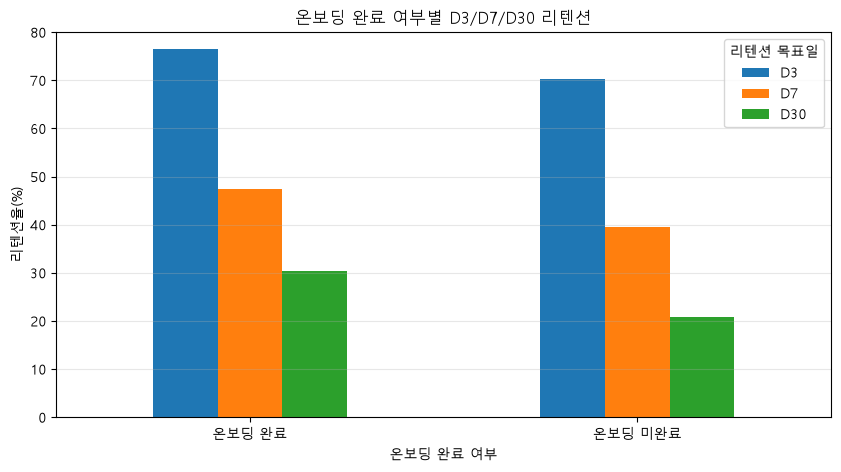

In [153]:
onboarding_plot_data = onboarding_retention_rate_table[["D3", "D7", "D30"]]

ax = onboarding_plot_data.plot(kind="bar", figsize=(10, 5))
ax.set_title("온보딩 완료 여부별 D3/D7/D30 리텐션")
ax.set_xlabel("온보딩 완료 여부")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 80)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="리텐션 목표일")
plt.xticks(rotation=0)
plt.show()

In [154]:
# 하락폭 -> ai가 만들어줌
onboarding_drop_table = onboarding_retention_rate_table[["D3", "D7", "D30"]].copy()

onboarding_drop_table["D3_to_D7_drop"] = (
    onboarding_drop_table["D3"] - onboarding_drop_table["D7"]
).round(2)

onboarding_drop_table["D7_to_D30_drop"] = (
    onboarding_drop_table["D7"] - onboarding_drop_table["D30"]
).round(2)

print("온보딩 완료 여부별 리텐션 하락폭")
display(onboarding_drop_table)

온보딩 완료 여부별 리텐션 하락폭


retention_label,D3,D7,D30,D3_to_D7_drop,D7_to_D30_drop
onboarding_group,,,,,
온보딩 완료,76.42,47.39,30.30,29.03,17.09
온보딩 미완료,70.21,39.53,20.72,30.68,18.81


### 분석 결과 해석
온보딩 완료자는 미완료자보다 D3, D7, D30 리텐션이 모두 높게 나타났다.

| 구분      |     D3 |     D7 |    D30 |
| ------- | -----: | -----: | -----: |
| 온보딩 완료  | 76.42% | 47.39% | 30.30% |
| 온보딩 미완료 | 70.21% | 39.53% | 20.72% |

온보딩 완료자는 미완료자보다 D7 리텐션이 약8%p, D30 리텐션이 약 9%p 높다.      
따라서 온보딩 완료 여부는 장기 잔존과 연결되는 신호로 볼 수 있다.

다만 D3 → D7 하락폭은 두 그룹 모두 약 29~31%p 수준으로 크게 나타난다.      
따라서 D3 → D7 이탈은 온보딩만으로 설명하기 어렵고, 이후 챌린지 탐색/참여 같은 초기 기능 경험을 추가로 확인할 필요가 있다.

## 2. 첫 7일 내 챌린지 탐색/참여 경험별 리텐션 분석

### 분석 목적
과제에서 제시한 핵심 가설은 **첫 7일 내 루틴 챌린지 경험자가 D30 리텐션이 더 높은지** 확인 하는것.      

다만 앞선 가입월별 코호트 분석에서 가장 큰 이탈 구간이 **D3 → D7**로 확인되었으므로, 여기서는 D30만 보지 않고 D3, D7, D30 리텐션을 함께 비교한다.       
특히나 첫 7일 내 챌린지 탐색/참여 경험 여부에 따라 **D3 → D7 하락폭**과 **D7 → D30 하락폭**이 어떻게 달라지는지 확인한다.


In [155]:
challenge_first7_event_count = (
    first_7day_event_log[
        first_7day_event_log["event_type"].isin(["챌린지_탐색", "챌린지참여"])
    ]
    .pivot_table(
        index="user_id",
        columns="event_type",
        values="event_time",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

challenge_first7_user = user_profile[["user_id"]].merge(
    challenge_first7_event_count,
    on="user_id",
    how="left"
)

challenge_first7_user[["챌린지_탐색", "챌린지참여"]] = (
    challenge_first7_user[["챌린지_탐색", "챌린지참여"]]
    .fillna(0)
)

challenge_first7_user["challenge_first7_group"] = np.select(
    [
        challenge_first7_user["챌린지참여"].gt(0),
        challenge_first7_user["챌린지_탐색"].gt(0)
    ],
    [
        "첫 7일 내 챌린지 참여",
        "첫 7일 내 챌린지 탐색만"
    ],
    default="첫 7일 내 챌린지 미경험"
)

challenge_group_summary = (
    challenge_first7_user
    .groupby("challenge_first7_group", as_index=False)
    .agg(user_count=("user_id", "nunique"))
)

display(challenge_group_summary)

,challenge_first7_group,user_count
0,첫 7일 내 챌린지 미경험,4053
1,첫 7일 내 챌린지 참여,8411
2,첫 7일 내 챌린지 탐색만,36


In [156]:
challenge_retention_base = behavior_retention_base.merge(
    challenge_first7_user[["user_id", "challenge_first7_group"]],
    on="user_id",
    how="left"
)

challenge_retention_summary = (
    challenge_retention_base[
        challenge_retention_base["is_retention_calculation_target"]
    ]
    .groupby(["challenge_first7_group", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

challenge_retention_summary["retention_rate"] = (
    challenge_retention_summary["retained_user_count"]
    / challenge_retention_summary["target_user_count"]
    * 100
).round(2)

challenge_group_order = [
    "첫 7일 내 챌린지 참여",
    "첫 7일 내 챌린지 탐색만",
    "첫 7일 내 챌린지 미경험"
]

challenge_retention_summary["challenge_first7_group"] = pd.Categorical(
    challenge_retention_summary["challenge_first7_group"],
    categories=challenge_group_order,
    ordered=True
)

challenge_retention_summary["retention_label"] = pd.Categorical(
    challenge_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

challenge_retention_summary = challenge_retention_summary.sort_values(
    ["challenge_first7_group", "retention_label"]
)

challenge_retention_rate_table = (
    challenge_retention_summary
    .pivot(index="challenge_first7_group", columns="retention_label", values="retention_rate")
    .reindex(challenge_group_order)
)

challenge_retention_count_table = (
    challenge_retention_summary
    .pivot(index="challenge_first7_group", columns="retention_label", values="retained_user_count")
    .reindex(challenge_group_order)
)

print("첫 7일 내 챌린지 경험별 리텐션율")
display(challenge_retention_rate_table)

print("첫 7일 내 챌린지 경험별 리텐션 유지 사용자 수")
display(challenge_retention_count_table)

첫 7일 내 챌린지 경험별 리텐션율


retention_label,D0,D3,D7,D30
challenge_first7_group,,,,
첫 7일 내 챌린지 참여,99.85,80.25,52.23,31.84
첫 7일 내 챌린지 탐색만,97.14,77.78,47.22,21.88
첫 7일 내 챌린지 미경험,99.77,57.90,24.12,11.10


첫 7일 내 챌린지 경험별 리텐션 유지 사용자 수


retention_label,D0,D3,D7,D30
challenge_first7_group,,,,
첫 7일 내 챌린지 참여,8197,6595,4269,2514
첫 7일 내 챌린지 탐색만,34,28,17,7
첫 7일 내 챌린지 미경험,3906,2261,946,422


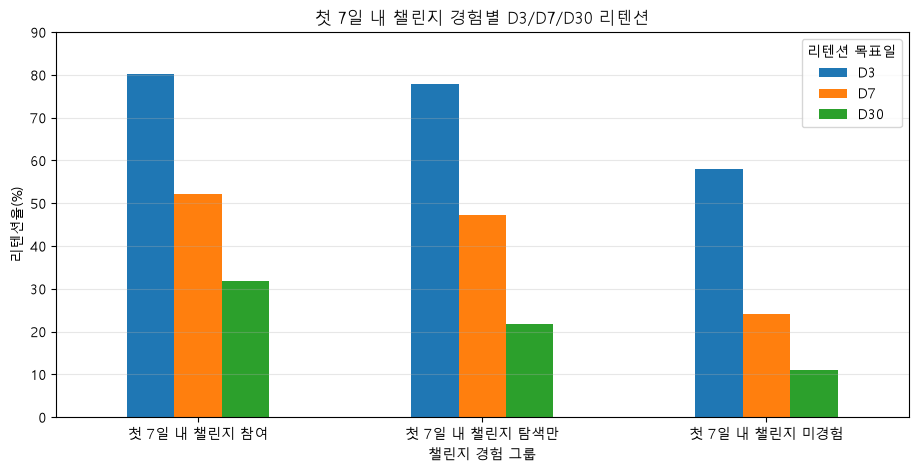

첫 7일 내 챌린지 경험별 리텐션 하락폭


retention_label,D3,D7,D30,D3_to_D7_drop,D7_to_D30_drop
challenge_first7_group,,,,,
첫 7일 내 챌린지 참여,80.25,52.23,31.84,28.02,20.39
첫 7일 내 챌린지 탐색만,77.78,47.22,21.88,30.56,25.34
첫 7일 내 챌린지 미경험,57.90,24.12,11.10,33.78,13.02


In [157]:
challenge_plot_data = challenge_retention_rate_table[["D3", "D7", "D30"]]

ax = challenge_plot_data.plot(kind="bar", figsize=(11, 5))
ax.set_title("첫 7일 내 챌린지 경험별 D3/D7/D30 리텐션")
ax.set_xlabel("챌린지 경험 그룹")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 90)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="리텐션 목표일")
plt.xticks(rotation=0)
plt.show()

challenge_drop_table = challenge_retention_rate_table[["D3", "D7", "D30"]].copy()

challenge_drop_table["D3_to_D7_drop"] = (
    challenge_drop_table["D3"] - challenge_drop_table["D7"]
).round(2)

challenge_drop_table["D7_to_D30_drop"] = (
    challenge_drop_table["D7"] - challenge_drop_table["D30"]
).round(2)

print("첫 7일 내 챌린지 경험별 리텐션 하락폭")
display(challenge_drop_table)

### 분석 결과 해석

첫 7일 내 챌린지 참여자는 미경험자보다 D3, D7, D30 리텐션이 모두 높게 나타났다.

| 구분 | D3 | D7 | D30 |
|---|---:|---:|---:|
| 첫 7일 내 챌린지 참여 | 80.25% | 52.23% | 31.84% |
| 첫 7일 내 챌린지 탐색만 | 77.78% | 47.22% | 21.88% |
| 첫 7일 내 챌린지 미경험 | 57.90% | 24.12% | 11.10% |

챌린지 참여자는 미경험자보다 D7 리텐션이 28.11%p, D30 리텐션이 20.74%p 높다.  
또한 D3 → D7 하락폭도 챌린지 참여자는 28.02%p, 미경험자는 33.78%p로 나타나 미경험자의 초기 이탈폭이 더 크다.

따라서 첫 7일 내 챌린지 참여 여부는 D3 → D7 이탈과 D30 장기 잔존을 설명하는 핵심 신호로 볼 수 있다.  
다만 `챌린지 탐색만` 그룹은 사용자 수가 36명으로 매우 작기 때문에, 해석은 참여자와 미경험자 비교를 중심으로 진행한다.


## 3. 첫 7일 내 알림 수신/오픈 여부별 리텐션 분석

### 분석 목적

알림이 리텐션과 연결되는지 확인하기 위해, 가입 후 7일 이내 알림 이벤트를 기준으로 사용자를 나눈다.      
알림은 단순히 수신 여부만 보는 것이 아니라, 실제로 사용자가 알림을 오픈했는지도 함께 비교한다.


In [158]:
notification_first7_event_count = (
    first_7day_event_log[
        first_7day_event_log["event_type"].isin(["알림수신", "알림오픈"])
    ]
    .pivot_table(
        index="user_id",
        columns="event_type",
        values="event_time",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

notification_first7_user = user_profile[["user_id"]].merge(
    notification_first7_event_count,
    on="user_id",
    how="left"
)

notification_first7_user[["알림수신", "알림오픈"]] = (
    notification_first7_user[["알림수신", "알림오픈"]]
    .fillna(0)
)

notification_first7_user["notification_first7_group"] = np.select(
    [
        notification_first7_user["알림오픈"].gt(0),
        notification_first7_user["알림수신"].gt(0)
    ],
    [
        "첫 7일 내 알림 오픈",
        "첫 7일 내 알림 수신만"
    ],
    default="첫 7일 내 알림 없음"
)

notification_group_summary = (
    notification_first7_user
    .groupby("notification_first7_group", as_index=False)
    .agg(user_count=("user_id", "nunique"))
)

display(notification_group_summary)

,notification_first7_group,user_count
0,첫 7일 내 알림 수신만,3988
1,첫 7일 내 알림 없음,4456
2,첫 7일 내 알림 오픈,4056


In [159]:
notification_retention_base = behavior_retention_base.merge(
    notification_first7_user[["user_id", "notification_first7_group"]],
    on="user_id",
    how="left"
)

notification_retention_summary = (
    notification_retention_base[
        notification_retention_base["is_retention_calculation_target"]
    ]
    .groupby(["notification_first7_group", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

notification_retention_summary["retention_rate"] = (
    notification_retention_summary["retained_user_count"]
    / notification_retention_summary["target_user_count"]
    * 100
).round(2)

notification_group_order = [
    "첫 7일 내 알림 오픈",
    "첫 7일 내 알림 수신만",
    "첫 7일 내 알림 없음"
]

notification_retention_summary["notification_first7_group"] = pd.Categorical(
    notification_retention_summary["notification_first7_group"],
    categories=notification_group_order,
    ordered=True
)

notification_retention_summary["retention_label"] = pd.Categorical(
    notification_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

notification_retention_summary = notification_retention_summary.sort_values(
    ["notification_first7_group", "retention_label"]
)

notification_retention_rate_table = (
    notification_retention_summary
    .pivot(index="notification_first7_group", columns="retention_label", values="retention_rate")
    .reindex(notification_group_order)
)

notification_retention_count_table = (
    notification_retention_summary
    .pivot(index="notification_first7_group", columns="retention_label", values="retained_user_count")
    .reindex(notification_group_order)
)

print("첫 7일 내 알림 수신/오픈 여부별 리텐션율")
display(notification_retention_rate_table)

print("첫 7일 내 알림 수신/오픈 여부별 리텐션 유지 사용자 수")
display(notification_retention_count_table)

첫 7일 내 알림 수신/오픈 여부별 리텐션율


retention_label,D0,D3,D7,D30
notification_first7_group,,,,
첫 7일 내 알림 오픈,99.90,88.84,55.02,32.53
첫 7일 내 알림 수신만,99.74,57.63,29.63,17.08
첫 7일 내 알림 없음,99.81,72.26,44.25,25.68


첫 7일 내 알림 수신/오픈 여부별 리텐션 유지 사용자 수


retention_label,D0,D3,D7,D30
notification_first7_group,,,,
첫 7일 내 알림 오픈,3970,3544,2186,1221
첫 7일 내 알림 수신만,3872,2220,1143,648
첫 7일 내 알림 없음,4295,3120,1903,1074


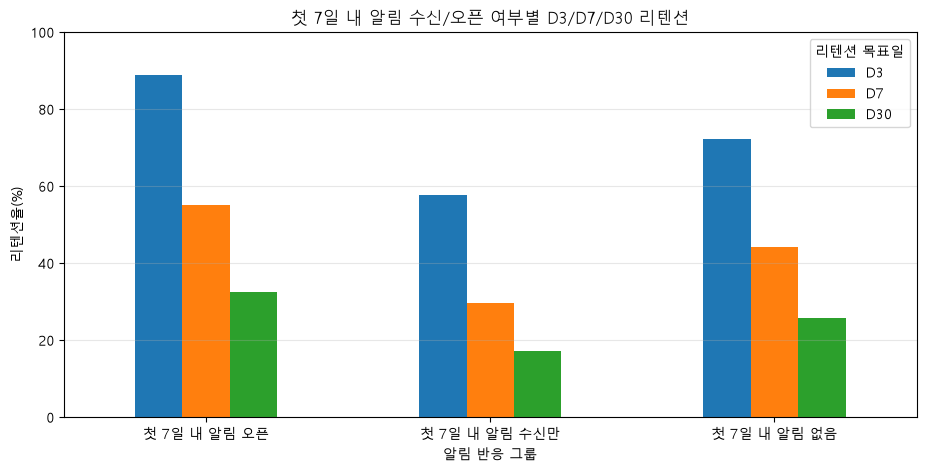

첫 7일 내 알림 수신/오픈 여부별 리텐션 하락폭


retention_label,D3,D7,D30,D3_to_D7_drop,D7_to_D30_drop
notification_first7_group,,,,,
첫 7일 내 알림 오픈,88.84,55.02,32.53,33.82,22.49
첫 7일 내 알림 수신만,57.63,29.63,17.08,28.00,12.55
첫 7일 내 알림 없음,72.26,44.25,25.68,28.01,18.57


In [160]:
notification_plot_data = notification_retention_rate_table[["D3", "D7", "D30"]]

ax = notification_plot_data.plot(kind="bar", figsize=(11, 5))
ax.set_title("첫 7일 내 알림 수신/오픈 여부별 D3/D7/D30 리텐션")
ax.set_xlabel("알림 반응 그룹")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="리텐션 목표일")
plt.xticks(rotation=0)
plt.show()

notification_drop_table = notification_retention_rate_table[["D3", "D7", "D30"]].copy()

notification_drop_table["D3_to_D7_drop"] = (
    notification_drop_table["D3"] - notification_drop_table["D7"]
).round(2)

notification_drop_table["D7_to_D30_drop"] = (
    notification_drop_table["D7"] - notification_drop_table["D30"]
).round(2)

print("첫 7일 내 알림 수신/오픈 여부별 리텐션 하락폭")
display(notification_drop_table)

### 분석 결과 해석

첫 7일 내 알림 오픈자는 D3, D7, D30 리텐션이 모두 가장 높게 나타났다.

| 구분 | D3 | D7 | D30 |
|---|---:|---:|---:|
| 첫 7일 내 알림 오픈 | 88.84% | 55.02% | 32.53% |
| 첫 7일 내 알림 수신만 | 57.63% | 29.63% | 17.08% |
| 첫 7일 내 알림 없음 | 72.26% | 44.25% | 25.68% |

알림 오픈자는 알림 없음 그룹보다 D7 리텐션이 10.77%p, D30 리텐션이 6.85%p 높다.  
반면 알림을 수신만 하고 오픈하지 않은 사용자는 알림 없음 그룹보다도 리텐션이 낮게 나타난다.

따라서 알림은 단순히 많이 보내는 것보다, 사용자가 실제로 오픈하고 앱 안의 행동으로 이어지게 만드는 것이 중요하다.  
다만 알림 오픈자는 원래 앱에 관심이 높은 사용자일 가능성도 있으므로, 알림 효과를 인과적으로 단정하기보다는 챌린지 참여를 유도하는 보조 수단으로 해석한다.


## 4. 가입경로별 리텐션 분석

### 분석 목적

2월 가입자 수가 급증했지만, 가입월별 코호트 분석에서는 2월 D30 리텐션이 가장 높게 나타났다.

따라서 가입경로별 리텐션을 확인하여, 특정 유입경로의 사용자 품질 차이가 리텐션 차이와 연결되는지 확인한다.


In [161]:
channel_retention_summary = (
    behavior_retention_base[
        behavior_retention_base["is_retention_calculation_target"]
    ]
    .groupby(["signup_channel", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

channel_retention_summary["retention_rate"] = (
    channel_retention_summary["retained_user_count"]
    / channel_retention_summary["target_user_count"]
    * 100
).round(2)

channel_retention_summary["retention_label"] = pd.Categorical(
    channel_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

channel_retention_summary = channel_retention_summary.sort_values(
    ["signup_channel", "retention_label"]
)

channel_retention_rate_table = (
    channel_retention_summary
    .pivot(index="signup_channel", columns="retention_label", values="retention_rate")
)

channel_retention_count_table = (
    channel_retention_summary
    .pivot(index="signup_channel", columns="retention_label", values="retained_user_count")
)

print("가입경로별 리텐션율")
display(channel_retention_rate_table)

print("가입경로별 리텐션 유지 사용자 수")
display(channel_retention_count_table)

가입경로별 리텐션율


retention_label,D0,D3,D7,D30
signup_channel,,,,
오가닉,99.89,73.16,43.41,25.34
퍼포먼스광고,99.76,73.01,42.89,24.87


가입경로별 리텐션 유지 사용자 수


retention_label,D0,D3,D7,D30
signup_channel,,,,
오가닉,5364,3939,2320,1306
퍼포먼스광고,6640,4848,2854,1604


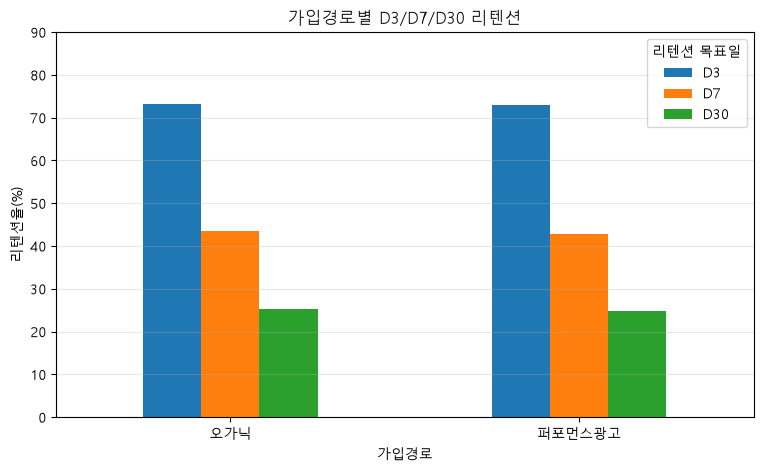

가입경로별 리텐션 하락폭


retention_label,D3,D7,D30,D3_to_D7_drop,D7_to_D30_drop
signup_channel,,,,,
오가닉,73.16,43.41,25.34,29.75,18.07
퍼포먼스광고,73.01,42.89,24.87,30.12,18.02


In [162]:
channel_plot_data = channel_retention_rate_table[["D3", "D7", "D30"]]

ax = channel_plot_data.plot(kind="bar", figsize=(9, 5))
ax.set_title("가입경로별 D3/D7/D30 리텐션")
ax.set_xlabel("가입경로")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 90)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="리텐션 목표일")
plt.xticks(rotation=0)
plt.show()

channel_drop_table = channel_retention_rate_table[["D3", "D7", "D30"]].copy()

channel_drop_table["D3_to_D7_drop"] = (
    channel_drop_table["D3"] - channel_drop_table["D7"]
).round(2)

channel_drop_table["D7_to_D30_drop"] = (
    channel_drop_table["D7"] - channel_drop_table["D30"]
).round(2)

print("가입경로별 리텐션 하락폭")
display(channel_drop_table)

### 분석 결과 해석

가입경로별 리텐션 차이는 D3, D7, D30 모두에서 크지 않다.

| 가입경로 | D3 | D7 | D30 |
|---|---:|---:|---:|
| 오가닉 | 73.16% | 43.41% | 25.34% |
| 퍼포먼스광고 | 73.01% | 42.89% | 24.87% |

오가닉 유입이 퍼포먼스광고 유입보다 약간 높지만, 차이는 매우 작다.  
D3 → D7 하락폭도 오가닉 29.75%p, 퍼포먼스광고 30.12%p로 거의 비슷하게 나타난다.

따라서 현재 결과만 보면 리텐션 하락의 핵심 원인을 특정 가입경로의 유입 품질 문제로 보기에는 근거가 약하다.  
2월 가입자 수 급증도 리텐션 악화로 바로 이어졌다고 보기보다는, 이후 온보딩/챌린지 경험 차이를 함께 확인하는 것이 더 중요하다.


## 5. 기기별 리텐션 분석

### 분석 목적

특정 기기 환경에서 리텐션이 낮게 나타나는지 확인한다.

기기별 차이가 크다면 사용성 문제나 기술적 이슈 가능성을 검토할 수 있다.


In [163]:
device_retention_summary = (
    behavior_retention_base[
        behavior_retention_base["is_retention_calculation_target"]
    ]
    .groupby(["device", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

device_retention_summary["retention_rate"] = (
    device_retention_summary["retained_user_count"]
    / device_retention_summary["target_user_count"]
    * 100
).round(2)

device_retention_summary["retention_label"] = pd.Categorical(
    device_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

device_retention_summary = device_retention_summary.sort_values(
    ["device", "retention_label"]
)

device_retention_rate_table = (
    device_retention_summary
    .pivot(index="device", columns="retention_label", values="retention_rate")
)

device_retention_count_table = (
    device_retention_summary
    .pivot(index="device", columns="retention_label", values="retained_user_count")
)

print("기기별 리텐션율")
display(device_retention_rate_table)

print("기기별 리텐션 유지 사용자 수")
display(device_retention_count_table)

기기별 리텐션율


retention_label,D0,D3,D7,D30
device,,,,
Android,99.76,73.21,43.27,25.28
iOS,99.86,73.02,43.06,24.91


기기별 리텐션 유지 사용자 수


retention_label,D0,D3,D7,D30
device,,,,
Android,5043,3709,2192,1234
iOS,6978,5094,2993,1678


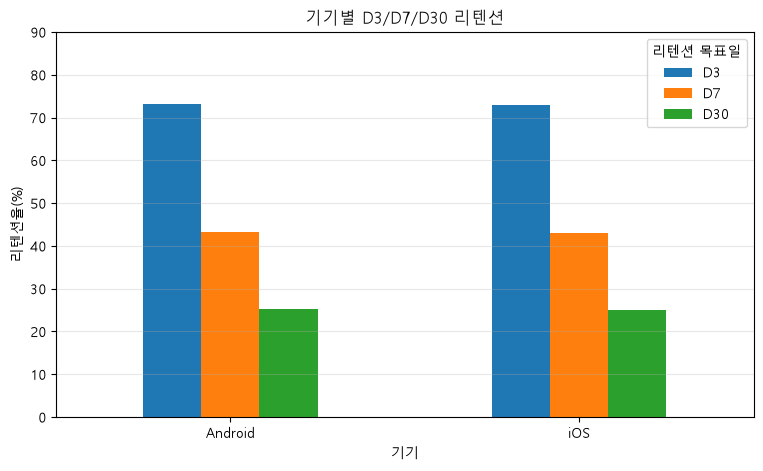

기기별 리텐션 하락폭


retention_label,D3,D7,D30,D3_to_D7_drop,D7_to_D30_drop
device,,,,,
Android,73.21,43.27,25.28,29.94,17.99
iOS,73.02,43.06,24.91,29.96,18.15


In [164]:
device_plot_data = device_retention_rate_table[["D3", "D7", "D30"]]

ax = device_plot_data.plot(kind="bar", figsize=(9, 5))
ax.set_title("기기별 D3/D7/D30 리텐션")
ax.set_xlabel("기기")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 90)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="리텐션 목표일")
plt.xticks(rotation=0)
plt.show()

device_drop_table = device_retention_rate_table[["D3", "D7", "D30"]].copy()

device_drop_table["D3_to_D7_drop"] = (
    device_drop_table["D3"] - device_drop_table["D7"]
).round(2)

device_drop_table["D7_to_D30_drop"] = (
    device_drop_table["D7"] - device_drop_table["D30"]
).round(2)

print("기기별 리텐션 하락폭")
display(device_drop_table)

### 분석 결과 해석

기기별 리텐션 차이도 D3, D7, D30 모두에서 크지 않다.

| 기기 | D3 | D7 | D30 |
|---|---:|---:|---:|
| Android | 73.21% | 43.27% | 25.28% |
| iOS | 73.02% | 43.06% | 24.91% |

Android와 iOS의 리텐션은 거의 비슷하게 나타난다.  
D3 → D7 하락폭도 Android 29.94%p, iOS 29.96%p로 차이가 거의 없다.

따라서 현재 데이터에서는 특정 기기 환경이 리텐션 하락의 핵심 원인이라고 보기는 어렵다.  
기기별 분석은 핵심 원인이라기보다, 기술적 이슈 가능성을 배제하는 보조 분석으로 보는 것이 적절하다.

## 리텐션 하락 원인 분석 1차 정리

이번 분석에서는 가입월별 코호트 분석에서 확인한 D3 → D7 이탈 문제를 바탕으로, 초기 행동 경험별 리텐션 차이를 확인했다.  
따라서 각 분석에서 D30 리텐션뿐 아니라 **D3 → D7 하락폭**도 함께 확인했다.

| 분석 항목 | 핵심 결과 | 해석 |
|---|---|---|
| 온보딩 완료 여부 | 완료자가 D3/D7/D30 모두 미완료자보다 높음 | 온보딩 완료는 장기 잔존과 연결되는 초기 신호지만, D3 → D7 이탈을 단독으로 설명하기는 어려움 |
| 첫 7일 내 챌린지 경험 | 참여자가 D7 52.23%, D30 31.84%로 미경험자보다 크게 높음 | D3 → D7 이탈과 D30 잔존을 설명하는 가장 강한 행동 신호 |
| 알림 수신/오픈 여부 | 알림 오픈자는 D30 32.53%로 높지만, 수신만 한 사용자는 17.08%로 낮음 | 단순 알림 발송보다 실제 오픈과 앱 내 행동 연결이 중요 |
| 가입경로 | 오가닉/퍼포먼스광고의 D3/D7/D30 차이가 작음 | 유입경로 자체가 핵심 원인이라고 보기는 어려움 |
| 기기 | Android/iOS의 D3/D7/D30 차이가 작음 | 특정 기기 환경 문제가 핵심 원인이라고 보기는 어려움 |

### 종합 해석

이번 리텐션 하락 원인 분석에서 확인한 핵심 내용은 다음과 같다.

1. 온보딩 완료자는 미완료자보다 D3/D7/D30 리텐션이 모두 높다.   
온보딩 완료자는 D30 리텐션이 30.30%로, 미완료자 20.72%보다 높게 나타났다.       
다만 D3 → D7 하락폭은 두 그룹 모두 크게 나타나므로, 온보딩만으로 D3 → D7 이탈을 모두 설명하기는 어렵다.

2. 첫 7일 내 챌린지 참여자는 미경험자보다 리텐션이 높다.            
챌린지 참여자는 D7 리텐션 52.23%, D30 리텐션 31.84%로 높게 나타났다.                
따라서 첫 7일 내 챌린지 참여 경험은 초기 이탈을 줄이고 장기 잔존으로 이어지는 중요한 행동 신호로 볼 수 있다.        

3. 다만, 챌린지 탐색 경험도 리텐션과 연결될 수 있지만, 실제 참여까지 이어진 사용자와는 차이가 있다.         
따라서 단순 탐색보다 실제 챌린지 참여 여부를 더 중요한 기준으로 보는 것이 적절하다.     

4. 알림은 단순 수신보다 오픈 여부가 더 중요하다.                
알림 오픈자는 D30 리텐션이 32.53%로 높게 나타난 반면, 알림을 수신만 하고 오픈하지 않은 사용자는 17.08%로 낮게 나타났다.             
즉, 알림 발송량 자체보다 사용자가 알림을 열고 앱 안의 행동으로 이어지는지가 더 중요하다.        

5. 가입경로와 기기별 리텐션 차이는 상대적으로 크지 않다.                
가입경로와 기기별 리텐션 차이는 온보딩, 챌린지, 알림 오픈 여부에서 나타난 차이보다 작게 나타났다.               
따라서 현재 리텐션 하락 원인은 유입경로나 기기 환경보다는 가입 초기 행동 경험과 더 관련이 있다고 볼 수 있다.        


